Supervised Learning on Census Income - 5.29.26 - lacaug0782

In [1]:
from datetime import datetime
from IPython.display import display, Markdown

todays_date = datetime.now().strftime("%Y-%m-%d")
student_id = "lacaug0782"

display(Markdown("# Supervised Learning on Census Income"))
display(Markdown(f"### Date: {todays_date}"))
display(Markdown(f"### Student ID: {student_id}"))

# Supervised Learning on Census Income

### Date: 2026-05-29

### Student ID: lacaug0782

In [2]:
display(Markdown("## Step 1.2: Load Dataset"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))

import pandas as pd

file_path = r"C:\Users\lacey\OneDrive\Documents\ECPI 2024\SDC485 AI_ML Data Analytics Methods_Modeling\3.4PA\census_income_dataset.csv"

data = pd.read_csv(file_path)

print(f"Data Shape: {data.shape}")

display(data.head())

## Step 1.2: Load Dataset

Date: 2026-05-29

Student ID: lacaug0782

Data Shape: (48842, 15)


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [3]:
display(Markdown("## Step 1.3: Initial Exploration"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))

data.columns = [
    "age",
    "workclass",
    "fnlwgt",
    "education",
    "education_num",
    "marital_status",
    "occupation",
    "relationship",
    "race",
    "sex",
    "capital_gain",
    "capital_loss",
    "hours_per_week",
    "native_country",
    "income"
]

print("First Few Rows:")
display(data.head())

print("\nDataset Information:")
print(data.info())

print("\nSummary Statistics:")
display(data.describe())

print("\nMissing Values:")
print(data.isnull().sum())


## Step 1.3: Initial Exploration

Date: 2026-05-29

Student ID: lacaug0782

First Few Rows:


,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K



Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             48842 non-null  int64 
 1   workclass       47879 non-null  object
 2   fnlwgt          48842 non-null  int64 
 3   education       48842 non-null  object
 4   education_num   48842 non-null  int64 
 5   marital_status  48842 non-null  object
 6   occupation      47876 non-null  object
 7   relationship    48842 non-null  object
 8   race            48842 non-null  object
 9   sex             48842 non-null  object
 10  capital_gain    48842 non-null  int64 
 11  capital_loss    48842 non-null  int64 
 12  hours_per_week  48842 non-null  int64 
 13  native_country  48568 non-null  object
 14  income          48842 non-null  object
dtypes: int64(6), object(9)
memory usage: 5.6+ MB
None

Summary Statistics:


,age,fnlwgt,education_num,capital_gain,capital_loss,hours_per_week
count,48842.000000,4.884200e+04,48842.000000,48842.000000,48842.000000,48842.000000
mean,38.643585,1.896641e+05,10.078089,1079.067626,87.502314,40.422382
std,13.710510,1.056040e+05,2.570973,7452.019058,403.004552,12.391444
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.175505e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.781445e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.376420e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.490400e+06,16.000000,99999.000000,4356.000000,99.000000



Missing Values:
age                 0
workclass         963
fnlwgt              0
education           0
education_num       0
marital_status      0
occupation        966
relationship        0
race                0
sex                 0
capital_gain        0
capital_loss        0
hours_per_week      0
native_country    274
income              0
dtype: int64


In [4]:
display(Markdown("## Step 2.1: Handle Missing Values"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))

for column in data.select_dtypes(include="object").columns:
    data[column] = data[column].fillna(
        data[column].mode()[0]
    )
print(data.isnull().sum())

## Step 2.1: Handle Missing Values

Date: 2026-05-29

Student ID: lacaug0782

age               0
workclass         0
fnlwgt            0
education         0
education_num     0
marital_status    0
occupation        0
relationship      0
race              0
sex               0
capital_gain      0
capital_loss      0
hours_per_week    0
native_country    0
income            0
dtype: int64


In [5]:
display(Markdown("## Step 2.2: Remove Duplicate Rows"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))

print("Shape Before:", data.shape)
data = data.drop_duplicates()
print("Shape After:", data.shape)

## Step 2.2: Remove Duplicate Rows

Date: 2026-05-29

Student ID: lacaug0782

Shape Before: (48842, 15)
Shape After: (48813, 15)


In [6]:
display(Markdown("## Step 2.3: Convert Target Variable"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))

data['income'] = data['income'].apply(
    lambda x: 1 if x == '>50K' else 0
)
print(data['income'].value_counts())

## Step 2.3: Convert Target Variable

Date: 2026-05-29

Student ID: lacaug0782

income
0    40974
1     7839
Name: count, dtype: int64


In [7]:
display(Markdown("## Step 2.4: One-Hot Encoding"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))

data_encoded = pd.get_dummies(
    data,
    drop_first=True
)
print(data_encoded.shape)
display(data_encoded.head())

## Step 2.4: One-Hot Encoding

Date: 2026-05-29

Student ID: lacaug0782

(48813, 101)


,age,fnlwgt,education_num,capital_gain,capital_loss,hours_per_week,income,workclass_Federal-gov,workclass_Local-gov,workclass_Never-worked,...,native_country_Portugal,native_country_Puerto-Rico,native_country_Scotland,native_country_South,native_country_Taiwan,native_country_Thailand,native_country_Trinadad&Tobago,native_country_United-States,native_country_Vietnam,native_country_Yugoslavia
0,39,77516,13,2174,0,40,0,False,False,False,...,False,False,False,False,False,False,False,True,False,False
1,50,83311,13,0,0,13,0,False,False,False,...,False,False,False,False,False,False,False,True,False,False
2,38,215646,9,0,0,40,0,False,False,False,...,False,False,False,False,False,False,False,True,False,False
3,53,234721,7,0,0,40,0,False,False,False,...,False,False,False,False,False,False,False,True,False,False
4,28,338409,13,0,0,40,0,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [8]:
display(Markdown("## Step 2.5: Train/Test Split"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))

from sklearn.model_selection import train_test_split
X = data_encoded.drop("income", axis=1)
y = data_encoded["income"]
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42
)
print("Training Records:", X_train.shape[0])
print("Testing Records:", X_test.shape[0])


## Step 2.5: Train/Test Split

Date: 2026-05-29

Student ID: lacaug0782

Training Records: 34169
Testing Records: 14644


In [9]:
display(Markdown("## Step 2.6: Feature Scaling"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(
    X_train
)
X_test_scaled = scaler.transform(
    X_test
)


## Step 2.6: Feature Scaling

Date: 2026-05-29

Student ID: lacaug0782

In [10]:
display(Markdown("## Step 3.1: Implement KNN"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))

from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier()
knn.fit(
    X_train_scaled,
    y_train
)
y_pred = knn.predict(
    X_test_scaled
)
print("KNN Model Complete")
print("First 20 Predicted Values:")
print(y_pred[:20])

print("\nFirst 20 Actual Values:")
print(y_test.values[:20])

print("\nPredicted Class Counts:")
print(pd.Series(y_pred).value_counts())

## Step 3.1: Implement KNN

Date: 2026-05-29

Student ID: lacaug0782

KNN Model Complete
First 20 Predicted Values:
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 1 0 0]

First 20 Actual Values:
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 0]

Predicted Class Counts:
0    13008
1     1636
Name: count, dtype: int64


In [11]:
display(Markdown("## Step 3.2: Evaluate Initial KNN"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)
print("Accuracy:",
      accuracy_score(y_test, y_pred))
print("Precision:",
      precision_score(y_test, y_pred))
print("Recall:",
      recall_score(y_test, y_pred))
print("F1 Score:",
      f1_score(y_test, y_pred))
print("\nClassification Report")
print(classification_report(
    y_test,
    y_pred
))
print("\nConfusion Matrix")
print(confusion_matrix(
    y_test,
    y_pred
))


## Step 3.2: Evaluate Initial KNN

Date: 2026-05-29

Student ID: lacaug0782

Accuracy: 0.8303742146954384
Precision: 0.4706601466992665
Recall: 0.3224455611390285
F1 Score: 0.3827037773359841

Classification Report
              precision    recall  f1-score   support

           0       0.88      0.93      0.90     12256
           1       0.47      0.32      0.38      2388

    accuracy                           0.83     14644
   macro avg       0.67      0.63      0.64     14644
weighted avg       0.81      0.83      0.82     14644


Confusion Matrix
[[11390   866]
 [ 1618   770]]


In [12]:
display(Markdown("## Step 4.1: GridSearchCV Hyperparameter Tuning"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))

from sklearn.model_selection import GridSearchCV
param_grid = {
    "n_neighbors": [3, 5, 7, 9],
    "weights": ["uniform", "distance"],
    "metric": [
        "euclidean",
        "manhattan",
        "minkowski"
    ]
}
grid_search = GridSearchCV(
    KNeighborsClassifier(),
    param_grid,
    cv=5,
    scoring="accuracy",
    verbose=2,
    n_jobs=-1
)
grid_search.fit(
    X_train_scaled,
    y_train
)
print("Best Parameters:")
print(grid_search.best_params_)
print("\nBest Score:")
print(grid_search.best_score_)


## Step 4.1: GridSearchCV Hyperparameter Tuning

Date: 2026-05-29

Student ID: lacaug0782

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best Parameters:
{'metric': 'euclidean', 'n_neighbors': 9, 'weights': 'uniform'}

Best Score:
0.8406742511819137


In [13]:
display(Markdown("## Step 4.2: Evaluate Tuned KNN"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))

best_knn = grid_search.best_estimator_
y_pred_tuned = best_knn.predict(
    X_test_scaled
)
print("Accuracy:",
      accuracy_score(
          y_test,
          y_pred_tuned
      ))
print("Precision:",
      precision_score(
          y_test,
          y_pred_tuned
      ))
print("Recall:",
      recall_score(
          y_test,
          y_pred_tuned
      ))
print("F1 Score:",
      f1_score(
          y_test,
          y_pred_tuned
      ))
print("\nClassification Report")
print(classification_report(
    y_test,
    y_pred_tuned
))
print("\nConfusion Matrix")
print(confusion_matrix(
    y_test,
    y_pred_tuned
))


## Step 4.2: Evaluate Tuned KNN

Date: 2026-05-29

Student ID: lacaug0782

Accuracy: 0.8365883638350178
Precision: 0.49821045096635647
Recall: 0.2914572864321608
F1 Score: 0.3677675033025099

Classification Report
              precision    recall  f1-score   support

           0       0.87      0.94      0.91     12256
           1       0.50      0.29      0.37      2388

    accuracy                           0.84     14644
   macro avg       0.69      0.62      0.64     14644
weighted avg       0.81      0.84      0.82     14644


Confusion Matrix
[[11555   701]
 [ 1692   696]]


## Step 5.1: Confusion Matrix Heatmap

Date: 2026-05-29

Student ID: lacaug0782

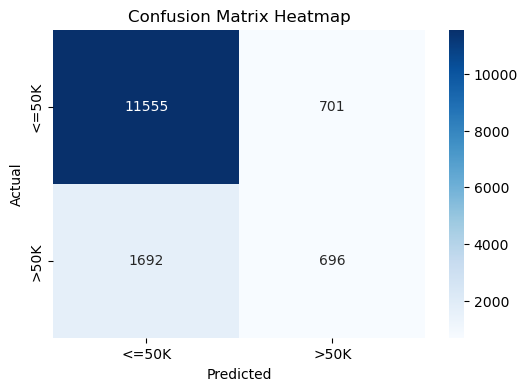

In [14]:
display(Markdown("## Step 5.1: Confusion Matrix Heatmap"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))

import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(
    y_test,
    y_pred_tuned
)
plt.figure(figsize=(6, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["<=50K", ">50K"],
    yticklabels=["<=50K", ">50K"]
)
plt.title("Confusion Matrix Heatmap")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


## Step 5.2: ROC Curve and AUC Score

Date: 2026-05-29

Student ID: lacaug0782

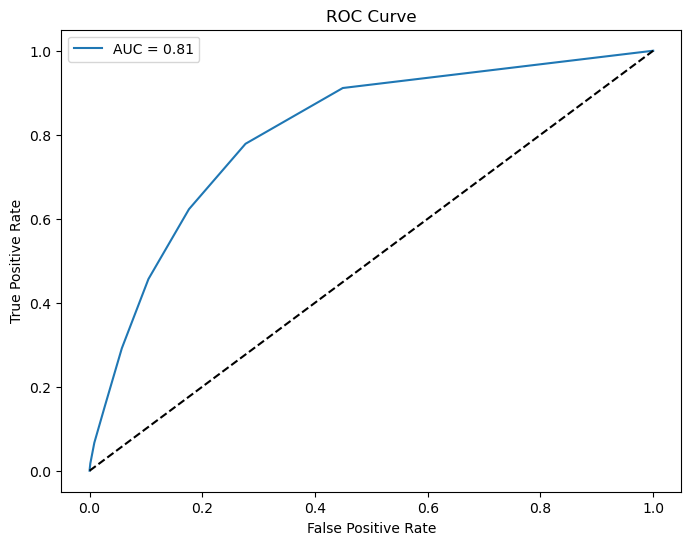

AUC Score: 0.8079287593319076


In [15]:
display(Markdown("## Step 5.2: ROC Curve and AUC Score"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))

from sklearn.metrics import (
    roc_curve,
    roc_auc_score
)
y_prob = best_knn.predict_proba(
    X_test_scaled
)[:, 1]
fpr, tpr, thresholds = roc_curve(
    y_test,
    y_prob
)
auc = roc_auc_score(
    y_test,
    y_prob
)
plt.figure(figsize=(8, 6))
plt.plot(
    fpr,
    tpr,
    label=f"AUC = {auc:.2f}"
)
plt.plot(
    [0, 1],
    [0, 1],
    'k--'
)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()
print("AUC Score:", auc)


1.	How well does the K-Nearest Neighbors model perform on the Census Income dataset before and after hyperparameter tuning?
•	Before hyperparameter tuning, the KNN model achieved an accuracy of approximately 83.0%. 
•	After hyperparameter tuning, the accuracy improved slightly to approximately 83.7%. 
•	The tuned model also showed a small improvement in precision, while recall and F1-score remained fairly similar. 
•	Overall, the model performed reasonably well at predicting individuals who earn $50K or less, but it was less effective at identifying individuals who earn more than $50K. 
•	Hyperparameter tuning helped improve the model, but the improvement was modest rather than dramatic.
2.	Which hyperparameters were selected as optimal by GridSearchCV, and how did they affect the model performance?
•	GridSearchCV tested 24 different parameter combinations using 5-fold cross-validation, resulting in 120 total model fits. 
•	The best combination was: 
o	n_neighbors = 9 
o	weights = "uniform" 
o	metric = "euclidean" 
•	Using 9 neighbors allowed the model to consider more nearby observations before making a prediction, which helped reduce some prediction errors. 
•	Uniform weighting means each of the 9 neighbors contributed equally to the prediction. 
•	The Euclidean distance metric measures the straight-line distance between data points and provided the best overall performance for this dataset. 
•	These settings increased the model accuracy from about 83.0% to 83.7%, making the tuned model the strongest version of KNN tested in this assignment.
